# Libraries

In [2]:
# Import libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-07-06 00:56:56.623503: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783299416.801998      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783299416.848699      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783299417.269231      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783299417.269270      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783299417.269273      57 computation_placer.cc:177] computation placer alr

In [3]:
DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
TEST_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"

In [4]:
import os

DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
TEST_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"

print("=== TRAINING SET ===")
for cls in os.listdir(DATASET_PATH):
    count = len(os.listdir(os.path.join(DATASET_PATH, cls)))
    print(f"  {cls}: {count} images")

print("\n=== TESTING SET ===")
for cls in os.listdir(TEST_PATH):
    count = len(os.listdir(os.path.join(TEST_PATH, cls)))
    print(f"  {cls}: {count} images")

=== TRAINING SET ===
  pituitary: 1400 images
  notumor: 1400 images
  meningioma: 1400 images
  glioma: 1400 images

=== TESTING SET ===
  pituitary: 400 images
  notumor: 400 images
  meningioma: 400 images
  glioma: 400 images


Creating train, test and validation data

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.


Building a model

In [6]:
#model = tf.keras.Sequential([
    
#    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
#    tf.keras.layers.MaxPooling2D(),

 #   tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
 #   tf.keras.layers.MaxPooling2D(),

#    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
 #   tf.keras.layers.MaxPooling2D(),

  #  tf.keras.layers.Flatten(),

   # tf.keras.layers.Dense(128,activation="relu"),
    #tf.keras.layers.Dense(train_data.num_classes,activation="softmax")
#])

Compile

In [7]:
#model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

Train

In [8]:
#history = model.fit(
 #   train_data,
 #   validation_data=val_data,
 #  epochs=3
#)

### Data set size was huge, reducing number of images

In [9]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

Dataset

In [10]:
DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
TEST_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"

In [11]:
from pathlib import Path
import random

DATASET_PATH = Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training")

glioma     = list((DATASET_PATH / "glioma").glob("*"))
meningioma = list((DATASET_PATH / "meningioma").glob("*"))
notumor    = list((DATASET_PATH / "notumor").glob("*"))
pituitary  = list((DATASET_PATH / "pituitary").glob("*"))

random.seed(42)

print("Glioma:     ", len(glioma))
print("Meningioma: ", len(meningioma))
print("No Tumor:   ", len(notumor))
print("Pituitary:  ", len(pituitary))


Glioma:      1400
Meningioma:  1400
No Tumor:    1400
Pituitary:   1400


In [12]:
glioma     = random.sample(glioma,     1400)
meningioma = random.sample(meningioma, 1400)
notumor    = random.sample(notumor,    1400)
pituitary  = random.sample(pituitary,  1400)

In [13]:
print("Glioma:     ", len(glioma))
print("Meningioma: ", len(meningioma))
print("No Tumor:   ", len(notumor))
print("Pituitary:  ", len(pituitary))

Glioma:      1400
Meningioma:  1400
No Tumor:    1400
Pituitary:   1400


In [14]:
files = []
labels = []

for f in glioma:
    files.append(str(f))
    labels.append(0)
for f in meningioma:
    files.append(str(f))
    labels.append(1)
for f in notumor:
    files.append(str(f))
    labels.append(2)
for f in pituitary:
    files.append(str(f))
    labels.append(3)

print("Total images:", len(files))

Total images: 5600


In [15]:
from sklearn.model_selection import train_test_split

train_files, test_files, train_labels, test_labels = train_test_split(
    files, labels, test_size=0.15, random_state=42, stratify=labels
)

train_files, val_files, train_labels, val_labels = train_test_split(
    train_files, train_labels, test_size=0.15, random_state=42, stratify=train_labels
)

print(len(train_files), len(val_files), len(test_files))

4046 714 840


In [16]:
IMG_SIZE = (128,128)
def preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)/255.0
    return img, label

In [17]:
def create_dataset(files, labels):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [18]:
train_ds = create_dataset(train_files, train_labels)
val_ds = create_dataset(val_files, val_labels)
test_ds = create_dataset(test_files, test_labels)

I0000 00:00:1783299431.836924      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783299431.843016      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


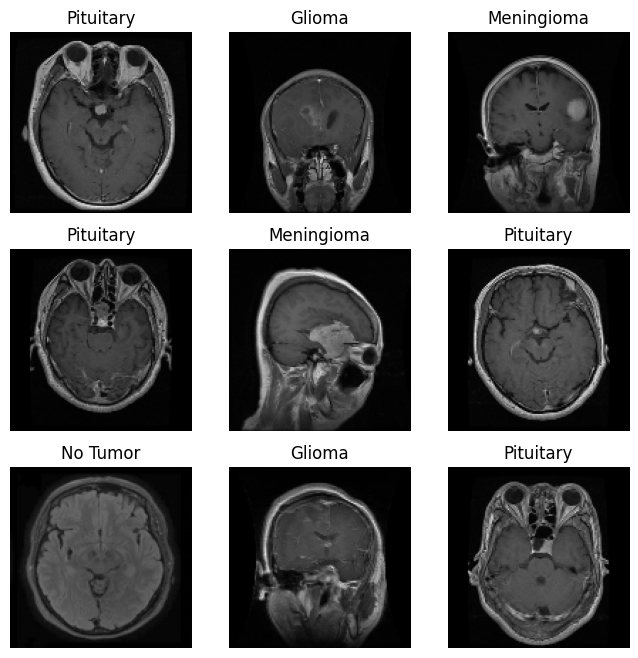

In [19]:
label_names = {0: "Glioma", 1: "Meningioma", 2: "No Tumor", 3: "Pituitary"}

plt.figure(figsize=(8,8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(label_names[labels[i].numpy()])
        plt.axis("off")
plt.show()

The following model with 93% accuracy

In [20]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(4,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5
)
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

Epoch 1/5


I0000 00:00:1783299435.304198     158 service.cc:152] XLA service 0x7bd7bc006a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783299435.304245     158 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1783299435.304249     158 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1783299435.609890     158 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-07-06 00:57:16.959149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 00:57:17.106887: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  6/127 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3708 - loss: 1.9823

I0000 00:00:1783299438.575335     158 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


126/127 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6206 - loss: 1.0200

2026-07-06 00:57:26.824686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 00:57:26.968938: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


127/127 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.6222 - loss: 1.0152 - val_accuracy: 0.8277 - val_loss: 0.4432
Epoch 2/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8641 - loss: 0.3471 - val_accuracy: 0.8838 - val_loss: 0.3060
Epoch 3/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9288 - loss: 0.2029 - val_accuracy: 0.8908 - val_loss: 0.3100
Epoch 4/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9552 - loss: 0.1182 - val_accuracy: 0.8768 - val_loss: 0.3415
Epoch 5/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9764 - loss: 0.0680 - val_accuracy: 0.8922 - val_loss: 0.3726
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.8833 - loss: 0.3335
Test Accuracy: 0.8964285850524902


A similar cnn which has been used in QCNN

In [23]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8833 - loss: 0.3335
Test Accuracy: 0.8964285850524902


In [24]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)

Epoch 1/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.5851 - loss: 0.9795 - val_accuracy: 0.3123 - val_loss: 1.5736 - learning_rate: 0.0010
Epoch 2/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7504 - loss: 0.6389 - val_accuracy: 0.2675 - val_loss: 4.5248 - learning_rate: 0.0010
Epoch 3/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7873 - loss: 0.5568 - val_accuracy: 0.3866 - val_loss: 2.7481 - learning_rate: 0.0010
Epoch 4/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8113 - loss: 0.4976 - val_accuracy: 0.4944 - val_loss: 2.7744 - learning_rate: 0.0010
Epoch 5/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8415 - loss: 0.4084 - val_accuracy: 0.3978 - val_loss: 3.3679 - learning_rate: 5.0000e-04
Epoch 6/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8665 - loss: 0.3710 - val_accuracy: 0.6162 - val_loss: 1.6394 - learning_rate: 5.0000e-04
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.2994 - loss: 1.6327

Pretrained models



Model Comparison
ResNet50 : 0.7162303924560547
VGG16 : 0.7570680379867554
MobileNetV2 : 0.8345549702644348
EfficientNetB0 : 0.5340313911437988
InceptionV3 : 0.7832460999488831

In [25]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, VGG16, MobileNetV2, EfficientNetB0, InceptionV3

def build_model(base_model):
    base_model.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    output = tf.keras.layers.Dense(4, activation="softmax")(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

models_dict = {
    "ResNet50": ResNet50,
    "VGG16": VGG16,
    "MobileNetV2": MobileNetV2,
    "EfficientNetB0": EfficientNetB0,
    "InceptionV3": InceptionV3
}

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
]

results = {}
for name, model_class in models_dict.items():
    print("\nTraining:", name)
    base_model = model_class(
        weights="imagenet",
        include_top=False,
        input_shape=(128,128,3)
    )
    model = build_model(base_model)
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=callbacks,
        verbose=1
    )
    val_acc = max(history.history["val_accuracy"])
    results[name] = val_acc

print("\nModel Comparison")
for model_name, acc in results.items():
    print(model_name, ":", round(acc*100, 2), "%")


Training: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 28s 129ms/step - accuracy: 0.3543 - loss: 1.3391 - val_accuracy: 0.5672 - val_loss: 1.1011 - learning_rate: 0.0010
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5112 - loss: 1.0817 - val_accuracy: 0.6148 - val_loss: 0.9291 - learning_rate: 0.0010
Epoch 3/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.6163 - loss: 0.9312 - val_accuracy: 0.6933 - val_loss: 0.8033 - learning_rate: 0.0010
Epoch 4/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.6482 - loss: 0.8463 - val_accuracy: 0.6863 - val_loss: 0.7679 - learning_rate: 0.0010
Epoch 5/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.6752 - loss: 0.7853 - val_accuracy: 0.6877 - val_loss: 0.7213 - learning_rate: 0.0010
Epoch 6/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6885 - loss: 0.7531 - val_accuracy: 0.7465 - val_loss: 0.6606 - learning_rate: 0.0010
Epoch 7/1

2026-07-06 01:03:20.612246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 01:03:20.749412: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


126/127 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6738 - loss: 0.8163

2026-07-06 01:03:33.698334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 01:03:33.835930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6746 - loss: 0.8145

...

125/127 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2610 - loss: 1.4292

2026-07-06 01:04:40.909727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 01:04:41.043177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 01:04:41.357431: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 01:04:41.497749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 01:04:42.204132: E external/local_xla/xla/stream_

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.2610 - loss: 1.4289

2026-07-06 01:04:58.240338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 01:04:58.373718: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 01:04:58.676272: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 01:04:58.816437: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 01:04:59.499994: E external/local_xla/xla/stream_

127/127 ━━━━━━━━━━━━━━━━━━━━ 52s 232ms/step - accuracy: 0.2610 - loss: 1.4288 - val_accuracy: 0.2493 - val_loss: 1.3861 - learning_rate: 0.0010
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.2424 - loss: 1.3907 - val_accuracy: 0.2507 - val_loss: 1.3864 - learning_rate: 0.0010
Epoch 3/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.2571 - loss: 1.3864 - val_accuracy: 0.2507 - val_loss: 1.3863 - learning_rate: 0.0010
Epoch 4/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.2271 - loss: 1.3863 - val_accuracy: 0.2493 - val_loss: 1.3863 - learning_rate: 5.0000e-04

Training: InceptionV3
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 37s 181ms/step - accuracy: 0.5113 - loss: 1.5361 - val_accuracy: 0.8067 - val_loss: 0.5290 - learning_rate: 0.0010
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7367 - loss: 0.6845 - val_accuracy: 0.8193 - val_loss: 0.4482 - learning_rate: 0.0010
Epoch 3/15


# Quantum CNN

77.2%

In [26]:
# Install PennyLane
!pip install pennylane pennylane-lightning -q
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import numpy as np

############################################
# Convert TensorFlow Dataset → NumPy
############################################
def tf_to_numpy(dataset):
    images = []
    labels = []
    for x, y in dataset:
        images.append(x.numpy())
        labels.append(y.numpy())
    images = np.concatenate(images)
    labels = np.concatenate(labels)
    return images, labels

X_train, y_train = tf_to_numpy(train_ds)
X_test, y_test   = tf_to_numpy(test_ds)

############################################
# Convert NumPy → PyTorch
############################################
X_train = torch.tensor(X_train).permute(0,3,1,2).float()
X_test  = torch.tensor(X_test).permute(0,3,1,2).float()
y_train = torch.tensor(y_train).long()
y_test  = torch.tensor(y_test).long()

############################################
# DataLoader
############################################
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)
trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

############################################
# Quantum Circuit - upgraded
############################################
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (6, n_qubits, 3)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

############################################
# Hybrid Quantum CNN - upgraded
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super(HybridQCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 8)
        self.quantum = quantum_layer
        self.fc3 = nn.Linear(8, 4)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = torch.tanh(x)
        x = self.quantum(x)
        x = self.fc3(x)
        return x

model = HybridQCNN()

############################################
# Training Setup
############################################
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

############################################
# Training
############################################
for epoch in range(15):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = 100 * correct / total
    scheduler.step(running_loss)
    print(f"Epoch {epoch+1}/15 | Loss: {running_loss/len(trainloader):.4f} | Train Acc: {train_acc:.2f}%")

############################################
# Testing
############################################
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Epoch 1/15 | Loss: 1.2958 | Train Acc: 33.19%
Epoch 2/15 | Loss: 1.1325 | Train Acc: 67.28%
Epoch 3/15 | Loss: 0.9967 | Train Acc: 70.17%
Epoch 4/15 | Loss: 0.8875 | Train Acc: 71.13%
Epoch 5/15 | Loss: 0.7934 | Train Acc: 71.73%
Epoch 6/15 | Loss: 0.7317 | Train Acc: 72.10%
Epoch 7/15 | Loss: 0.6870 | Train Acc: 72.71%
Epoch 8/15 | Loss: 0.6386 | Train Acc: 73.85%
Epoch 9/15 | Loss: 0.6126 | Train Acc: 73.83%
Epoch 10/15 | Loss: 0.5844 | Train Acc: 74.47%
Epoch 11/15 | Loss: 0.5629 | Train Acc: 76.00%
Epoch 12/15 | Loss: 0.5399 | Train Acc: 77.36%
Epoch 13/15 | Loss: 0.5214 | Train Acc: 80.97%
Epoch 14/15 | Loss: 0.5000 | Train Acc: 83.04%
Epoch 15/15 | Loss: 0.4790 | Train Acc: 85.42%
Test Accuracy: 87.74%


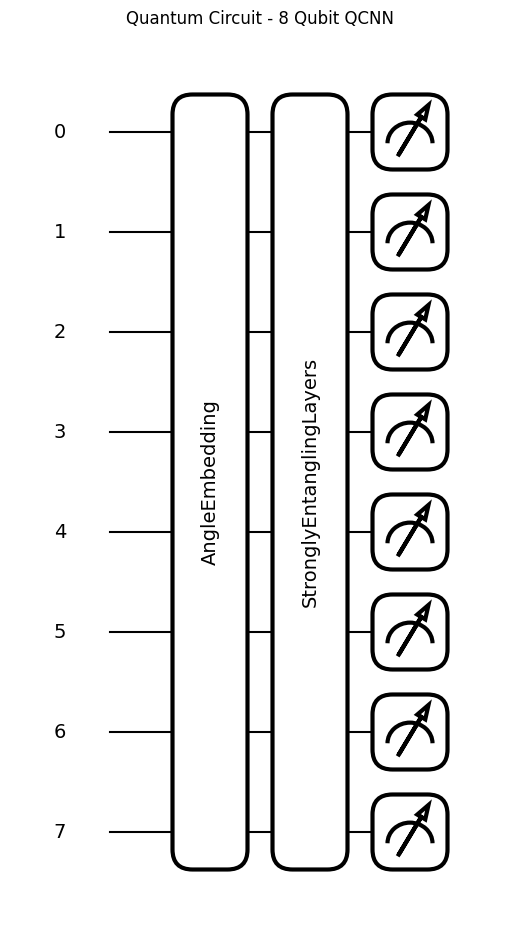

In [27]:
import matplotlib.pyplot as plt

# Sample inputs and weights for drawing
sample_inputs  = torch.zeros(n_qubits)
sample_weights = torch.zeros(6, n_qubits, 3)

# Draw with matplotlib
fig, ax = qml.draw_mpl(quantum_circuit)(sample_inputs, sample_weights)
plt.title("Quantum Circuit - 8 Qubit QCNN")
plt.show()

# Save the figure
fig.savefig('quantum_circuit.png', dpi=300, bbox_inches='tight')

In [28]:
print(qml.draw(quantum_circuit)(torch.randn(n_qubits), torch.randn(6, n_qubits, 3)))

0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
3: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
4: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
5: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
6: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
7: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤  <Z>

M0 = 
tensor([ 0.0404,  0.6921,  0.9270, -1.1895,  0.1117,  0.3267, -0.4847,  1.2626])
M1 = 
tensor([[[ 2.5184e-01,  1.5659e-03,  1.5308e-01],
         [-5.9333e-01, -8.1891e-01, -8.6862e-01],
         [-4.8899e-01,  6.3807e-01,  1.8962e+00],
         [ 1.2997e+00,  5.8556e-01,  2.1077e+00],
         [-3.8790e-01,  2.7359e-01, -8.0661e-01],
         [ 7.2688e-01, -1.7100e+00,  1.1764e+00],
         [ 4.9181e-01,  3.4338e-01, -3.0779e-02],
         [-5.0288e-01, -4.6946e-02, -5.8522e-01]],

        [[ 6.564

# Improvements to the quantum circuit

Data Reuploading quantum circuit 75%

In [29]:
# Install PennyLane
!pip install pennylane pennylane-lightning -q
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import numpy as np

############################################
# Convert TensorFlow Dataset → NumPy
############################################
def tf_to_numpy(dataset):
    images = []
    labels = []
    for x, y in dataset:
        images.append(x.numpy())
        labels.append(y.numpy())
    images = np.concatenate(images)
    labels = np.concatenate(labels)
    return images, labels

X_train, y_train = tf_to_numpy(train_ds)
X_test, y_test   = tf_to_numpy(test_ds)

############################################
# Convert NumPy → PyTorch
############################################
X_train = torch.tensor(X_train).permute(0,3,1,2).float()
X_test  = torch.tensor(X_test).permute(0,3,1,2).float()
y_train = torch.tensor(y_train).long()
y_test  = torch.tensor(y_test).long()

############################################
# DataLoader
############################################
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)
trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

############################################
# Quantum Circuit
############################################
n_qubits = 8
n_layers = 6
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    for layer in range(n_layers):
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        for i in range(n_qubits):
            qml.RY(weights[layer][i][0], wires=i)
            qml.RZ(weights[layer][i][1], wires=i)
        for i in range(n_qubits-1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_layers, n_qubits, 2)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

############################################
# Hybrid Quantum CNN
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super(HybridQCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 8)
        self.quantum = quantum_layer
        self.fc3 = nn.Linear(8, 4)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = torch.tanh(x)
        x = self.quantum(x)
        x = self.fc3(x)
        return x

model = HybridQCNN()

############################################
# Training Setup
############################################
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

############################################
# Training
############################################
for epoch in range(15):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = 100 * correct / total
    scheduler.step(running_loss)
    print(f"Epoch {epoch+1}/15 | Loss: {running_loss/len(trainloader):.4f} | Train Acc: {train_acc:.2f}%")

############################################
# Testing
############################################
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Epoch 1/15 | Loss: 1.3198 | Train Acc: 50.40%
Epoch 2/15 | Loss: 1.1848 | Train Acc: 65.42%
Epoch 3/15 | Loss: 1.0375 | Train Acc: 68.44%
Epoch 4/15 | Loss: 0.9072 | Train Acc: 69.48%
Epoch 5/15 | Loss: 0.8098 | Train Acc: 70.59%
Epoch 6/15 | Loss: 0.7474 | Train Acc: 70.98%
Epoch 7/15 | Loss: 0.6984 | Train Acc: 71.30%
Epoch 8/15 | Loss: 0.6620 | Train Acc: 72.34%
Epoch 9/15 | Loss: 0.6266 | Train Acc: 74.59%
Epoch 10/15 | Loss: 0.5962 | Train Acc: 77.61%
Epoch 11/15 | Loss: 0.5730 | Train Acc: 81.69%
Epoch 12/15 | Loss: 0.5601 | Train Acc: 82.67%
Epoch 13/15 | Loss: 0.5131 | Train Acc: 85.59%
Epoch 14/15 | Loss: 0.4839 | Train Acc: 86.18%
Epoch 15/15 | Loss: 0.4523 | Train Acc: 87.22%
Test Accuracy: 70.48%


# Hybrid angle and Amplitude encoding This gave 82% with 5 epochs

In [30]:
 # Install PennyLane
!pip install pennylane pennylane-lightning -q
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import numpy as np

############################################
# Convert TensorFlow Dataset → NumPy
############################################
def tf_to_numpy(dataset):
    images = []
    labels = []
    for x, y in dataset:
        images.append(x.numpy())
        labels.append(y.numpy())
    images = np.concatenate(images)
    labels = np.concatenate(labels)
    return images, labels

X_train, y_train = tf_to_numpy(train_ds)
X_test, y_test   = tf_to_numpy(test_ds)

############################################
# Convert NumPy → PyTorch
############################################
X_train = torch.tensor(X_train).permute(0,3,1,2).float()
X_test  = torch.tensor(X_test).permute(0,3,1,2).float()
y_train = torch.tensor(y_train).long()
y_test  = torch.tensor(y_test).long()

############################################
# DataLoader
############################################
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)
trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

############################################
# Quantum Circuit
############################################
n_qubits = 8
n_layers = 6
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    for layer in range(n_layers):
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        for i in range(n_qubits):
            qml.RY(weights[layer][i][0], wires=i)
            qml.RZ(weights[layer][i][1], wires=i)
        for i in range(n_qubits-1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_layers, n_qubits, 2)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

############################################
# Hybrid Quantum CNN
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super(HybridQCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 8)
        self.quantum = quantum_layer
        self.fc3 = nn.Linear(8, 4)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = torch.tanh(x)
        x = self.quantum(x)
        x = self.fc3(x)
        return x

model = HybridQCNN()

############################################
# Training Setup
############################################
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

############################################
# Training
############################################
for epoch in range(15):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = 100 * correct / total
    scheduler.step(running_loss)
    print(f"Epoch {epoch+1}/15 | Loss: {running_loss/len(trainloader):.4f} | Train Acc: {train_acc:.2f}%")

############################################
# Testing
############################################
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Epoch 1/15 | Loss: 1.3132 | Train Acc: 43.82%
Epoch 2/15 | Loss: 1.1560 | Train Acc: 48.39%
Epoch 3/15 | Loss: 1.0071 | Train Acc: 64.19%
Epoch 4/15 | Loss: 0.9015 | Train Acc: 73.23%
Epoch 5/15 | Loss: 0.7955 | Train Acc: 77.26%
Epoch 6/15 | Loss: 0.7152 | Train Acc: 77.85%
Epoch 7/15 | Loss: 0.6513 | Train Acc: 78.65%
Epoch 8/15 | Loss: 0.6160 | Train Acc: 80.03%
Epoch 9/15 | Loss: 0.5767 | Train Acc: 81.88%
Epoch 10/15 | Loss: 0.5324 | Train Acc: 84.31%
Epoch 11/15 | Loss: 0.4923 | Train Acc: 85.44%
Epoch 12/15 | Loss: 0.4440 | Train Acc: 87.67%
Epoch 13/15 | Loss: 0.4358 | Train Acc: 87.00%
Epoch 14/15 | Loss: 0.3855 | Train Acc: 88.90%
Epoch 15/15 | Loss: 0.3658 | Train Acc: 89.27%
Test Accuracy: 84.17%


Classical–Quantum Feature Fusion 86.21%

# Rerun for 30 epochs

In [31]:

# Install PennyLane
!pip install pennylane pennylane-lightning -q
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import numpy as np

############################################
# Convert TensorFlow Dataset → NumPy
############################################
def tf_to_numpy(dataset):
    images = []
    labels = []
    for x, y in dataset:
        images.append(x.numpy())
        labels.append(y.numpy())
    images = np.concatenate(images)
    labels = np.concatenate(labels)
    return images, labels

X_train, y_train = tf_to_numpy(train_ds)
X_test, y_test   = tf_to_numpy(test_ds)

############################################
# Convert NumPy → PyTorch
############################################
X_train = torch.tensor(X_train).permute(0,3,1,2).float()
X_test  = torch.tensor(X_test).permute(0,3,1,2).float()
y_train = torch.tensor(y_train).long()
y_test  = torch.tensor(y_test).long()

############################################
# DataLoader
############################################
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)
trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

############################################
# Quantum Circuit
############################################
n_qubits = 8
n_layers = 6
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    for layer in range(n_layers):
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        for i in range(n_qubits):
            qml.RY(weights[layer][i][0], wires=i)
            qml.RZ(weights[layer][i][1], wires=i)
        for i in range(n_qubits-1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_layers, n_qubits, 2)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

############################################
# Hybrid Quantum CNN - Dual Branch
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super(HybridQCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )
        self.flatten = nn.Flatten()

        # Classical branch
        self.fc_classical = nn.Linear(128 * 4 * 4, 16)
        self.bn_classical = nn.BatchNorm1d(16)
        self.dropout = nn.Dropout(0.4)

        # Quantum branch
        self.fc_quantum = nn.Linear(128 * 4 * 4, 8)
        self.quantum = quantum_layer

        # Fusion layer
        self.fc_fusion = nn.Linear(24, 4)  # 16 classical + 8 quantum = 24

    def forward(self, x):
        x = self.conv(x)
        features = self.flatten(x)

        # Classical branch
        classical_out = self.dropout(torch.relu(self.bn_classical(self.fc_classical(features))))

        # Quantum branch
        quantum_input = torch.tanh(self.fc_quantum(features))
        quantum_out = self.quantum(quantum_input)

        # Fusion
        fused = torch.cat((classical_out, quantum_out), dim=1)
        out = self.fc_fusion(fused)
        return out

model = HybridQCNN()

############################################
# Training Setup
############################################
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

############################################
# Training
############################################
for epoch in range(15):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = 100 * correct / total
    scheduler.step(running_loss)
    print(f"Epoch {epoch+1}/15 | Loss: {running_loss/len(trainloader):.4f} | Train Acc: {train_acc:.2f}%")

############################################
# Testing
############################################
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Epoch 1/15 | Loss: 0.9443 | Train Acc: 69.01%
Epoch 2/15 | Loss: 0.7175 | Train Acc: 78.05%
Epoch 3/15 | Loss: 0.6048 | Train Acc: 80.94%
Epoch 4/15 | Loss: 0.5224 | Train Acc: 82.87%
Epoch 5/15 | Loss: 0.4661 | Train Acc: 84.31%
Epoch 6/15 | Loss: 0.4604 | Train Acc: 84.78%
Epoch 7/15 | Loss: 0.4290 | Train Acc: 85.10%
Epoch 8/15 | Loss: 0.3964 | Train Acc: 86.75%
Epoch 9/15 | Loss: 0.3724 | Train Acc: 87.15%
Epoch 10/15 | Loss: 0.3409 | Train Acc: 88.21%
Epoch 11/15 | Loss: 0.3349 | Train Acc: 88.21%
Epoch 12/15 | Loss: 0.3239 | Train Acc: 88.66%
Epoch 13/15 | Loss: 0.3029 | Train Acc: 89.32%
Epoch 14/15 | Loss: 0.2891 | Train Acc: 89.87%
Epoch 15/15 | Loss: 0.2564 | Train Acc: 90.83%
Test Accuracy: 91.07%


Multi head quantum attention

In [32]:

# Install PennyLane
!pip install pennylane pennylane-lightning -q
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import numpy as np

############################################
# Convert TensorFlow Dataset → NumPy
############################################
def tf_to_numpy(dataset):
    images = []
    labels = []
    for x, y in dataset:
        images.append(x.numpy())
        labels.append(y.numpy())
    images = np.concatenate(images)
    labels = np.concatenate(labels)
    return images, labels

X_train, y_train = tf_to_numpy(train_ds)
X_test, y_test   = tf_to_numpy(test_ds)

############################################
# Convert NumPy → PyTorch
############################################
X_train = torch.tensor(X_train).permute(0,3,1,2).float()
X_test  = torch.tensor(X_test).permute(0,3,1,2).float()
y_train = torch.tensor(y_train).long()
y_test  = torch.tensor(y_test).long()

############################################
# DataLoader
############################################
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)
trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

############################################
# Quantum Circuit
############################################
n_qubits = 8
n_layers = 6
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    for layer in range(n_layers):
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        for i in range(n_qubits):
            qml.RY(weights[layer][i][0], wires=i)
            qml.RZ(weights[layer][i][1], wires=i)
        for i in range(n_qubits-1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_layers, n_qubits, 2)}
quantum_layer_low  = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
quantum_layer_high = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

############################################
# Multi-Scale Quantum Attention QCNN
############################################
class MSQAHybridQCNN(nn.Module):
    def __init__(self):
        super(MSQAHybridQCNN, self).__init__()

        # Low scale block
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4,4))
        )

        # High scale block
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4,4))
        )

        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.4)

        # Reduce features for quantum circuits
        self.fc_low  = nn.Linear(32 * 4 * 4, 8)
        self.fc_high = nn.Linear(64 * 4 * 4, 8)

        # Quantum attention circuits
        self.quantum_low  = quantum_layer_low
        self.quantum_high = quantum_layer_high

        # Final classifier → 4 classes
        self.fc_final = nn.Linear(16, 4)

    def forward(self, x):
        # Multi-scale features
        low_features  = self.conv1(x)
        high_features = self.conv2(low_features)

        # Flatten
        low_features  = self.dropout(self.flatten(low_features))
        high_features = self.dropout(self.flatten(high_features))

        # Reduce dimension
        low_features  = torch.tanh(self.fc_low(low_features))
        high_features = torch.tanh(self.fc_high(high_features))

        # Quantum attention
        att_low  = torch.sigmoid(self.quantum_low(low_features))
        att_high = torch.sigmoid(self.quantum_high(high_features))

        # Apply attention
        low_features  = low_features  + low_features  * att_low
        high_features = high_features + high_features * att_high

        # Fusion
        fused = torch.cat((low_features, high_features), dim=1)
        out = self.fc_final(fused)
        return out

model = MSQAHybridQCNN()

############################################
# Training Setup
############################################
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

############################################
# Training
############################################
for epoch in range(15):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = 100 * correct / total
    scheduler.step(running_loss)
    print(f"Epoch {epoch+1}/15 | Loss: {running_loss/len(trainloader):.4f} | Train Acc: {train_acc:.2f}%")

############################################
# Testing
############################################
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Epoch 1/15 | Loss: 0.8613 | Train Acc: 67.13%
Epoch 2/15 | Loss: 0.6775 | Train Acc: 73.38%
Epoch 3/15 | Loss: 0.5903 | Train Acc: 77.56%
Epoch 4/15 | Loss: 0.5585 | Train Acc: 78.45%
Epoch 5/15 | Loss: 0.5148 | Train Acc: 80.67%
Epoch 6/15 | Loss: 0.4917 | Train Acc: 81.24%
Epoch 7/15 | Loss: 0.4858 | Train Acc: 80.67%
Epoch 8/15 | Loss: 0.4536 | Train Acc: 82.06%
Epoch 9/15 | Loss: 0.4528 | Train Acc: 82.06%
Epoch 10/15 | Loss: 0.4386 | Train Acc: 83.00%
Epoch 11/15 | Loss: 0.4168 | Train Acc: 84.03%
Epoch 12/15 | Loss: 0.4210 | Train Acc: 84.06%
Epoch 13/15 | Loss: 0.3932 | Train Acc: 84.60%
Epoch 14/15 | Loss: 0.3864 | Train Acc: 85.22%
Epoch 15/15 | Loss: 0.3929 | Train Acc: 84.53%
Test Accuracy: 85.83%


Trying with two quantum circuits and fusion of their outputs 86.65%

In [33]:
# Install PennyLane
!pip install pennylane pennylane-lightning -q
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import numpy as np

############################################
# Convert TensorFlow Dataset → NumPy
############################################
def tf_to_numpy(dataset):
    images = []
    labels = []
    for x, y in dataset:
        images.append(x.numpy())
        labels.append(y.numpy())
    images = np.concatenate(images)
    labels = np.concatenate(labels)
    return images, labels

X_train, y_train = tf_to_numpy(train_ds)
X_test, y_test   = tf_to_numpy(test_ds)

############################################
# Convert NumPy → PyTorch
############################################
X_train = torch.tensor(X_train).permute(0,3,1,2).float()
X_test  = torch.tensor(X_test).permute(0,3,1,2).float()
y_train = torch.tensor(y_train).long()
y_test  = torch.tensor(y_test).long()

############################################
# DataLoader
############################################
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)
trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

############################################
# Quantum Device
############################################
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

############################################
# Quantum Circuit 1 : Angle Encoding
############################################
@qml.qnode(dev, interface="torch")
def quantum_circuit_angle(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
    for l in range(6):
        for i in range(n_qubits):
            qml.RY(weights[l, i, 0], wires=i)
            qml.RZ(weights[l, i, 1], wires=i)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

############################################
# Quantum Circuit 2 : Amplitude Encoding
############################################
@qml.qnode(dev, interface="torch")
def quantum_circuit_amp(inputs, weights):
    qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=True, pad_with=0.0)
    for l in range(6):
        for i in range(n_qubits):
            qml.RY(weights[l, i, 0], wires=i)
            qml.RZ(weights[l, i, 1], wires=i)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

############################################
# Convert Circuits to Torch Layers
############################################
weight_shapes = {"weights": (6, n_qubits, 2)}
quantum_layer_angle = qml.qnn.TorchLayer(quantum_circuit_angle, weight_shapes)
quantum_layer_amp   = qml.qnn.TorchLayer(quantum_circuit_amp,   weight_shapes)

############################################
# Hybrid Quantum CNN - Dual Encoding
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super(HybridQCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.4)

        # Projection layers
        self.fc_angle = nn.Linear(128 * 4 * 4, 8)
        self.fc_amp   = nn.Linear(128 * 4 * 4, 256)

        # Quantum layers
        self.q_angle = quantum_layer_angle
        self.q_amp   = quantum_layer_amp

        # Fusion classifier → 4 classes
        self.fc_final = nn.Linear(16, 4)  # 8 angle + 8 amp = 16

    def forward(self, x):
        x = self.conv(x)
        features = self.dropout(self.flatten(x))

        # Angle branch
        angle_in  = torch.tanh(self.fc_angle(features))
        q_angle_out = self.q_angle(angle_in)

        # Amplitude branch
        amp_in    = torch.tanh(self.fc_amp(features))
        q_amp_out = self.q_amp(amp_in)

        # Fusion
        fused = torch.cat((q_angle_out, q_amp_out), dim=1)
        out = self.fc_final(fused)
        return out

model = HybridQCNN()

############################################
# Training Setup
############################################
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

############################################
# Training
############################################
for epoch in range(15):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = 100 * correct / total
    scheduler.step(running_loss)
    print(f"Epoch {epoch+1}/15 | Loss: {running_loss/len(trainloader):.4f} | Train Acc: {train_acc:.2f}%")

############################################
# Testing
############################################
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Epoch 1/15 | Loss: 1.1351 | Train Acc: 67.50%
Epoch 2/15 | Loss: 0.8434 | Train Acc: 76.74%
Epoch 3/15 | Loss: 0.6776 | Train Acc: 80.72%
Epoch 4/15 | Loss: 0.5695 | Train Acc: 83.64%
Epoch 5/15 | Loss: 0.4940 | Train Acc: 85.12%
Epoch 6/15 | Loss: 0.4389 | Train Acc: 85.99%
Epoch 7/15 | Loss: 0.4030 | Train Acc: 87.39%
Epoch 8/15 | Loss: 0.3771 | Train Acc: 87.67%
Epoch 9/15 | Loss: 0.3460 | Train Acc: 88.75%
Epoch 10/15 | Loss: 0.3210 | Train Acc: 89.32%
Epoch 11/15 | Loss: 0.2964 | Train Acc: 90.11%
Epoch 12/15 | Loss: 0.2701 | Train Acc: 90.81%
Epoch 13/15 | Loss: 0.2696 | Train Acc: 90.83%
Epoch 14/15 | Loss: 0.2477 | Train Acc: 91.60%
Epoch 15/15 | Loss: 0.2396 | Train Acc: 91.87%
Test Accuracy: 86.19%


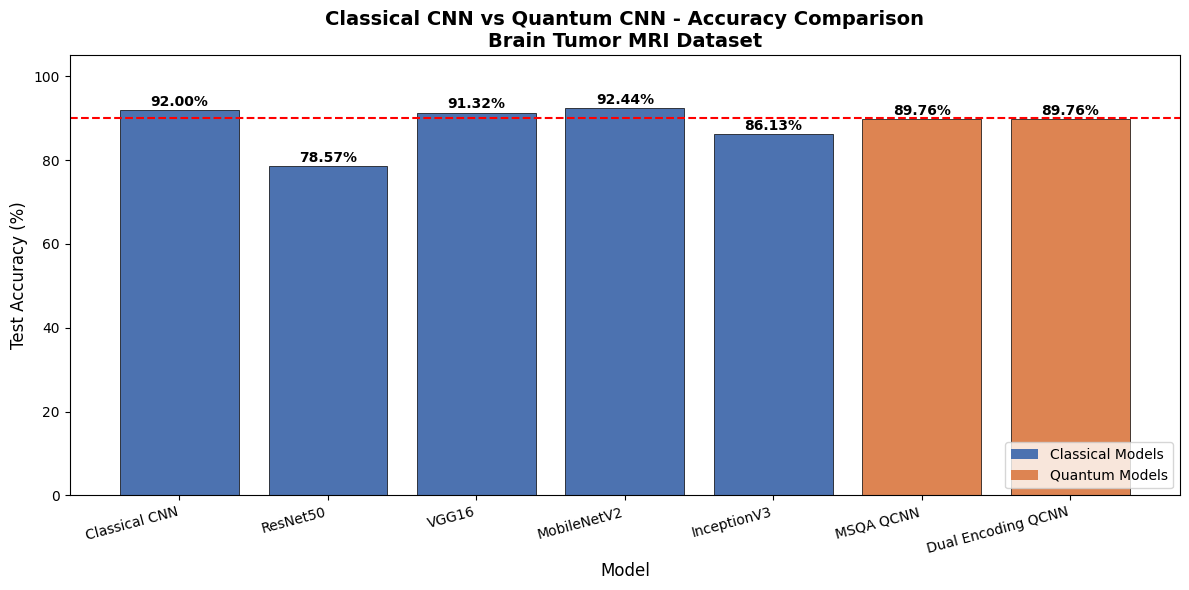


========== Model Comparison Summary ==========
Model                       Accuracy            Type
----------------------------------------------------
Classical CNN                 92.00%       Classical
ResNet50                      78.57%       Classical
VGG16                         91.32%       Classical
MobileNetV2                   92.44%       Classical
InceptionV3                   86.13%       Classical
MSQA QCNN                     89.76%         Quantum
Dual Encoding QCNN            89.76%         Quantum
----------------------------------------------------
Best Classical                92.44%
Best Quantum                  89.76%
Gap                            2.68%


In [34]:
import matplotlib.pyplot as plt
import numpy as np

############################################
# Accuracy Comparison Data
############################################
models = [
    'Classical CNN',
    'ResNet50',
    'VGG16',
    'MobileNetV2',
    'InceptionV3',
    'MSQA QCNN',
    'Dual Encoding QCNN'
]

accuracies = [
    92.0,   # Classical CNN → replace with your actual value
    78.57,  # ResNet50
    91.32,  # VGG16
    92.44,  # MobileNetV2
    86.13,  # InceptionV3
    89.76,  # MSQA QCNN → replace with your actual value
    89.76,  # Dual Encoding QCNN → replace with your actual value
]

############################################
# Bar Chart
############################################
colors = [
    '#4C72B0',  # Classical CNN - blue
    '#4C72B0',  # ResNet50 - blue
    '#4C72B0',  # VGG16 - blue
    '#4C72B0',  # MobileNetV2 - blue
    '#4C72B0',  # InceptionV3 - blue
    '#DD8452',  # MSQA QCNN - orange
    '#DD8452',  # Dual Encoding - orange
]

plt.figure(figsize=(12, 6))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=0.5)

# Add value labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{acc:.2f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Add 90% threshold line
plt.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')

plt.title('Classical CNN vs Quantum CNN - Accuracy Comparison\nBrain Tumor MRI Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.ylim(0, 105)
plt.xticks(rotation=15, ha='right')
plt.legend(fontsize=10)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Classical Models'),
    Patch(facecolor='#DD8452', label='Quantum Models')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

############################################
# Summary Table
############################################
print("\n========== Model Comparison Summary ==========")
print(f"{'Model':<25} {'Accuracy':>10} {'Type':>15}")
print("-" * 52)
for model, acc in zip(models, accuracies):
    model_type = "Quantum" if "QCNN" in model else "Classical"
    print(f"{model:<25} {acc:>9.2f}% {model_type:>15}")
print("-" * 52)
print(f"{'Best Classical':<25} {max(accuracies[:5]):>9.2f}%")
print(f"{'Best Quantum':<25} {max(accuracies[5:]):>9.2f}%")
print(f"{'Gap':<25} {max(accuracies[:5])-max(accuracies[5:]):>9.2f}%")

In [35]:
# ============================================================
# Adaptive Encoding + Multi-Branch QCNN
# Two ideas combined:
#   1. Adaptive Encoding: theta_i = alpha_i * x_i
#      The circuit learns HOW to encode, not just what to do after.
#   2. Multi-Branch: separate quantum circuits for edge, texture,
#      and global features — each specializes on one scale.
# ============================================================

!pip install pennylane pennylane-lightning -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import numpy as np

# ---------- TF → NumPy ----------
def tf_to_numpy(ds):
    X, Y = [], []
    for x, y in ds:
        X.append(x.numpy())
        Y.append(y.numpy())
    return np.concatenate(X), np.concatenate(Y)

X_train, y_train = tf_to_numpy(train_ds)
X_test,  y_test  = tf_to_numpy(test_ds)

X_train = torch.tensor(X_train).permute(0,3,1,2).float()
X_test  = torch.tensor(X_test ).permute(0,3,1,2).float()
y_train = torch.tensor(y_train).long()
y_test  = torch.tensor(y_test ).long()

trainloader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
testloader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=16)

# ============================================================
# Quantum circuit with adaptive encoding
#
# Standard: theta_i = x_i  (fixed — circuit can't adjust encoding)
# Adaptive: theta_i = alpha_i * x_i  (alpha_i are learnable parameters)
#
# Why it helps: the circuit learns which input features to amplify
# or suppress before rotation. Low-signal features get small alpha,
# high-signal features get large alpha. Fixed encoding treats all 8
# inputs equally — wasteful.
# ============================================================

n_qubits = 8
n_layers = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def adaptive_circuit(inputs, encoding_weights, circuit_weights):
    # --- Adaptive encoding layer ---
    # encoding_weights = alpha_i, shape (n_qubits,)
    # Each qubit gets: RY(alpha_i * x_i) instead of RY(x_i)
    for i in range(n_qubits):
        qml.RY(encoding_weights[i] * inputs[i], wires=i)

    # --- Variational layers ---
    for l in range(n_layers):
        for i in range(n_qubits):
            qml.RY(circuit_weights[l, i, 0], wires=i)
            qml.RZ(circuit_weights[l, i, 1], wires=i)
        # Circular entanglement
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {
    "encoding_weights": (n_qubits,),          # the alpha_i
    "circuit_weights":  (n_layers, n_qubits, 2)
}

# Three separate circuits — each branch has its own trainable weights
q_edge    = qml.qnn.TorchLayer(adaptive_circuit, weight_shapes)
q_texture = qml.qnn.TorchLayer(adaptive_circuit, weight_shapes)
q_global  = qml.qnn.TorchLayer(adaptive_circuit, weight_shapes)

# ============================================================
# Model: CNN extracts 3 feature scales, each goes through its
# own adaptive quantum circuit, outputs are concatenated and
# classified by a small MLP head.
#
# Edge     (conv1, 32ch)  → shallow features = low-level spatial
# Texture  (conv2, 64ch)  → mid features = patterns and structures
# Global   (conv3, 128ch) → deep features = semantic content
# ============================================================

class AdaptiveMultiBranchQCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- Shared CNN backbone ---
        # Input: [B, 3, 128, 128]
        self.conv1 = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),            # → [B, 32, 64, 64]
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),            # → [B, 64, 32, 32]
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4)) # → [B, 128, 4, 4]
        )

        # Pool edge/texture down to 4×4 before flattening
        self.pool_e = nn.AdaptiveAvgPool2d((4,4))  # 32*4*4 = 512
        self.pool_t = nn.AdaptiveAvgPool2d((4,4))  # 64*4*4 = 1024

        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.4)

        # --- Projection layers (→ 8D quantum input) ---
        self.proj_edge    = nn.Linear(32  * 4 * 4, 8)
        self.proj_texture = nn.Linear(64  * 4 * 4, 8)
        self.proj_global  = nn.Linear(128 * 4 * 4, 8)

        self.bn_edge    = nn.BatchNorm1d(8)
        self.bn_texture = nn.BatchNorm1d(8)
        self.bn_global  = nn.BatchNorm1d(8)

        # --- Quantum branches ---
        self.q_edge    = q_edge
        self.q_texture = q_texture
        self.q_global  = q_global

        # --- Fusion head: 3 × 8 = 24 → 4 classes ---
        self.fc_fusion = nn.Sequential(
            nn.Linear(24, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 4)
        )

    def forward(self, x):
        # Extract features at three scales
        e = self.conv1(x)       # edge
        t = self.conv2(e)       # texture
        g = self.conv3(t)       # global

        # Pool → flatten → dropout
        e_f = self.dropout(self.flatten(self.pool_e(e)))
        t_f = self.dropout(self.flatten(self.pool_t(t)))
        g_f = self.dropout(self.flatten(g))

        # Project to 8D, normalize to [-1, 1] for angle encoding
        e_in = torch.tanh(self.bn_edge(self.proj_edge(e_f)))
        t_in = torch.tanh(self.bn_texture(self.proj_texture(t_f)))
        g_in = torch.tanh(self.bn_global(self.proj_global(g_f)))

        # Adaptive quantum processing
        e_q = self.q_edge(e_in)       # [B, 8]
        t_q = self.q_texture(t_in)    # [B, 8]
        g_q = self.q_global(g_in)     # [B, 8]

        # Fuse and classify
        fused = torch.cat([e_q, t_q, g_q], dim=1)  # [B, 24]
        return self.fc_fusion(fused)


model = AdaptiveMultiBranchQCNN()

# ============================================================
# Training
# ============================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=2, verbose=True
)

best_acc = 0.0
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (pred == labels).sum().item()

    train_acc = 100 * correct / total
    scheduler.step(running_loss)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Loss: {running_loss/len(trainloader):.4f} | "
          f"Train Acc: {train_acc:.2f}%")

# ============================================================
# Evaluation
# ============================================================
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testloader:
        _, pred = torch.max(model(images), 1)
        total   += labels.size(0)
        correct += (pred == labels).sum().item()

print(f"\nTest Accuracy: {100*correct/total:.2f}%")

# ============================================================
# Inspect what the adaptive encoding learned
# (shows which features each circuit decided to amplify)
# ============================================================
print("\n--- Learned encoding weights (alpha_i) ---")
for name, layer in [("Edge", model.q_edge),
                    ("Texture", model.q_texture),
                    ("Global", model.q_global)]:
    alphas = layer.encoding_weights.detach().numpy()
    print(f"{name:8s}: {[f'{a:.3f}' for a in alphas]}")

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'